# Yelp Dataset — Download & Preprocessing

**Purpose:** Download the raw Yelp Open Dataset, filter to Tampa Bay restaurants/bars/coffee & tea, build the three density tiers, and save compressed `.csv.gz` files ready to push to GitHub via GitHub Desktop (< 100 MB each).

**After running this notebook:**
1. Push the `.csv.gz` files from `preprocessed_data/` to your GitHub repo using GitHub Desktop
2. In the main notebook, use the "Load preprocessed data" cell instead of Sections 2–3.7

**Requirements:** ~4.3 GB free disk space for the raw dataset (temporary).

---

## 1. Setup & Dependencies

In [1]:
!pip install gdown pandas matplotlib --quiet

import os
import tarfile
import pandas as pd
import matplotlib.pyplot as plt

print("Setup complete.")


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
Setup complete.


## 2. Download Yelp Dataset from Google Drive

In [2]:
DATA_DIR = "yelp_data/"
TAR_PATH = "yelp_dataset.tar"

if not os.path.exists(os.path.join(DATA_DIR, "yelp_academic_dataset_business.json")):
    print("Downloading Yelp dataset from Google Drive...")
    !gdown "1wzVfcOyvjh5u3ZpC__f6-5Gg13m0V_Rr" -O {TAR_PATH} --fuzzy

    print("Extracting tar archive...")
    os.makedirs(DATA_DIR, exist_ok=True)
    with tarfile.open(TAR_PATH, "r") as tar:
        tar.extractall(DATA_DIR)

    # Handle nested subfolder if present
    extracted = os.listdir(DATA_DIR)
    if len(extracted) == 1 and os.path.isdir(os.path.join(DATA_DIR, extracted[0])):
        subfolder = os.path.join(DATA_DIR, extracted[0])
        for f in os.listdir(subfolder):
            os.rename(os.path.join(subfolder, f), os.path.join(DATA_DIR, f))
        os.rmdir(subfolder)

    os.remove(TAR_PATH)
    print("\u2713 Dataset downloaded and extracted. Tar file removed.")
else:
    print("\u2713 Yelp data already extracted.")

print("\nFiles in data directory:")
for f in sorted(os.listdir(DATA_DIR)):
    size_mb = os.path.getsize(os.path.join(DATA_DIR, f)) / (1024**2)
    print(f"  {f:50s} {size_mb:>8.1f} MB")

✓ Yelp data already extracted.

Files in data directory:
  Dataset_User_Agreement.pdf                              0.1 MB
  yelp_academic_dataset_business.json                   113.4 MB
  yelp_academic_dataset_checkin.json                    273.7 MB
  yelp_academic_dataset_review.json                    5094.4 MB
  yelp_academic_dataset_tip.json                        172.2 MB
  yelp_academic_dataset_user.json                      3207.5 MB


## 3. Load Raw JSON Files

In [3]:
def load_yelp_json(filename, chunksize=50_000):
    """Load a Yelp JSON Lines file into a DataFrame (chunked for memory)."""
    filepath = os.path.join(DATA_DIR, filename)
    if not os.path.exists(filepath):
        raise FileNotFoundError(f"File not found: {filepath}")
    chunks = []
    for chunk in pd.read_json(filepath, lines=True, chunksize=chunksize):
        chunks.append(chunk)
    df = pd.concat(chunks, ignore_index=True)
    print(f"  \u2713 {filename}: {df.shape[0]:,} rows \u00d7 {df.shape[1]} cols")
    return df

print("Loading Yelp dataset files...")
print("=" * 60)
business_df = load_yelp_json("yelp_academic_dataset_business.json")
review_df   = load_yelp_json("yelp_academic_dataset_review.json")
user_df     = load_yelp_json("yelp_academic_dataset_user.json")
checkin_df  = load_yelp_json("yelp_academic_dataset_checkin.json")
tip_df      = load_yelp_json("yelp_academic_dataset_tip.json")
print("=" * 60)
print("\u2713 All files loaded.")

Loading Yelp dataset files...
  ✓ yelp_academic_dataset_business.json: 150,346 rows × 14 cols
  ✓ yelp_academic_dataset_review.json: 6,990,280 rows × 9 cols
  ✓ yelp_academic_dataset_user.json: 1,987,897 rows × 22 cols
  ✓ yelp_academic_dataset_checkin.json: 131,930 rows × 2 cols
  ✓ yelp_academic_dataset_tip.json: 908,915 rows × 5 cols
✓ All files loaded.


## 4. Geographic & Category Filtering

In [4]:
fl_biz = business_df[business_df['state'] == 'FL'].copy()
print(f"Florida businesses: {fl_biz.shape[0]:,}")
print(f"\nTop 20 FL cities:")
print(fl_biz['city'].value_counts().head(20).to_string())

top_cities = fl_biz['city'].value_counts().head(15).index.tolist()
print(f"\nTampa Bay metro cities (top 15): {top_cities}")

florida_biz = fl_biz[fl_biz['city'].isin(top_cities)].copy()
print(f"Metro businesses: {florida_biz.shape[0]:,}")

category_keywords = ['Restaurant', 'Bar', 'Coffee & Tea', 'Coffee', 'Tea']

def has_target_category(cats):
    if pd.isna(cats):
        return False
    return any(kw.lower() in cats.lower() for kw in category_keywords)

florida_biz = florida_biz[florida_biz['categories'].apply(has_target_category)].copy()
print(f"\nRestaurants, Bars & Coffee/Tea in Tampa Bay: {florida_biz.shape[0]:,}")

all_target_biz_ids = set(florida_biz['business_id'].unique())
print(f"Target business IDs: {len(all_target_biz_ids):,}")

Florida businesses: 26,330

Top 20 FL cities:
city
Tampa               9048
Clearwater          2221
Saint Petersburg    1663
St. Petersburg      1185
Brandon             1033
Largo               1002
Palm Harbor          665
New Port Richey      604
Lutz                 591
Riverview            588
Wesley Chapel        560
Pinellas Park        512
Dunedin              490
Spring Hill          400
Tarpon Springs       398
St Petersburg        387
Seminole             359
Oldsmar              286
Valrico              276
Port Richey          270

Tampa Bay metro cities (top 15): ['Tampa', 'Clearwater', 'Saint Petersburg', 'St. Petersburg', 'Brandon', 'Largo', 'Palm Harbor', 'New Port Richey', 'Lutz', 'Riverview', 'Wesley Chapel', 'Pinellas Park', 'Dunedin', 'Spring Hill', 'Tarpon Springs']
Metro businesses: 20,960

Restaurants, Bars & Coffee/Tea in Tampa Bay: 8,012
Target business IDs: 8,012


## 5. Three-Tier Density Filtering

In [5]:
def iterative_filter(reviews, user_min, biz_min, tier_name, max_iter=5):
    """Iteratively filter reviews until user/business counts stabilize."""
    df = reviews.copy()
    for iteration in range(max_iter):
        n_before = len(df)
        user_counts = df['user_id'].value_counts()
        df = df[df['user_id'].isin(user_counts[user_counts >= user_min].index)]
        biz_counts = df['business_id'].value_counts()
        df = df[df['business_id'].isin(biz_counts[biz_counts >= biz_min].index)]
        n_after = len(df)
        print(f"  Iter {iteration+1}: {n_before:,} \u2192 {n_after:,} "
              f"({df['user_id'].nunique():,} users, {df['business_id'].nunique():,} biz)")
        if n_before == n_after:
            print("  \u2713 Stable.")
            break
    user_ids = set(df['user_id'].unique())
    biz_ids = set(df['business_id'].unique())
    sparsity = 1 - len(df) / (len(user_ids) * len(biz_ids))
    print(f"\n{'='*60}")
    print(f"{tier_name}")
    print(f"  Reviews:    {len(df):,}")
    print(f"  Users:      {len(user_ids):,}  (\u2265{user_min} reviews)")
    print(f"  Businesses: {len(biz_ids):,}  (\u2265{biz_min} reviews)")
    print(f"  Sparsity:   {sparsity:.4%}")
    print(f"{'='*60}")
    return df, user_ids, biz_ids, sparsity

reviews_raw = review_df[review_df['business_id'].isin(all_target_biz_ids)].copy()
print(f"Raw reviews for target businesses: {reviews_raw.shape[0]:,}\n")

print("--- TIER 1 ---")
reviews_t1, t1_user_ids, t1_biz_ids, t1_sparsity = iterative_filter(
    reviews_raw, user_min=5, biz_min=20, tier_name="TIER 1 \u2014 FULL SCOPE (Churn + EDA)")

print("\n--- TIER 2 ---")
reviews_t2, t2_user_ids, t2_biz_ids, t2_sparsity = iterative_filter(
    reviews_t1, user_min=10, biz_min=30, tier_name="TIER 2 \u2014 MEDIUM DENSITY (Item-to-Item)")

print("\n--- TIER 3 ---")
reviews_t3, t3_user_ids, t3_biz_ids, t3_sparsity = iterative_filter(
    reviews_t1, user_min=20, biz_min=30, tier_name="TIER 3 \u2014 DENSE CORE (SVD + NCF)")

Raw reviews for target businesses: 649,052

--- TIER 1 ---
  Iter 1: 649,052 → 336,031 (25,435 users, 3,882 biz)
  Iter 2: 336,031 → 324,573 (22,821 users, 3,777 biz)
  Iter 3: 324,573 → 323,807 (22,665 users, 3,769 biz)
  Iter 4: 323,807 → 323,775 (22,657 users, 3,769 biz)
  Iter 5: 323,775 → 323,775 (22,657 users, 3,769 biz)
  ✓ Stable.

TIER 1 — FULL SCOPE (Churn + EDA)
  Reviews:    323,775
  Users:      22,657  (≥5 reviews)
  Businesses: 3,769  (≥20 reviews)
  Sparsity:   99.6208%

--- TIER 2 ---
  Iter 1: 323,775 → 207,055 (8,856 users, 2,355 biz)
  Iter 2: 207,055 → 193,292 (7,555 users, 2,244 biz)
  Iter 3: 193,292 → 191,170 (7,390 users, 2,221 biz)
  Iter 4: 191,170 → 190,782 (7,356 users, 2,218 biz)
  Iter 5: 190,782 → 190,746 (7,352 users, 2,218 biz)

TIER 2 — MEDIUM DENSITY (Item-to-Item)
  Reviews:    190,746
  Users:      7,352  (≥10 reviews)
  Businesses: 2,218  (≥30 reviews)
  Sparsity:   98.8303%

--- TIER 3 ---
  Iter 1: 323,775 → 130,006 (3,469 users, 1,737 biz)
  It

## 6. Tier Comparison

       Tier      Purpose  User Min  Biz Min  Reviews  Users  Businesses Sparsity
  T1 (Full)  Churn + EDA         5       20   323775  22657        3769   99.62%
T2 (Medium) Item-to-Item        10       30   190746   7352        2218   98.83%
 T3 (Dense)    SVD + NCF        20       30   100669   2279        1390   96.82%


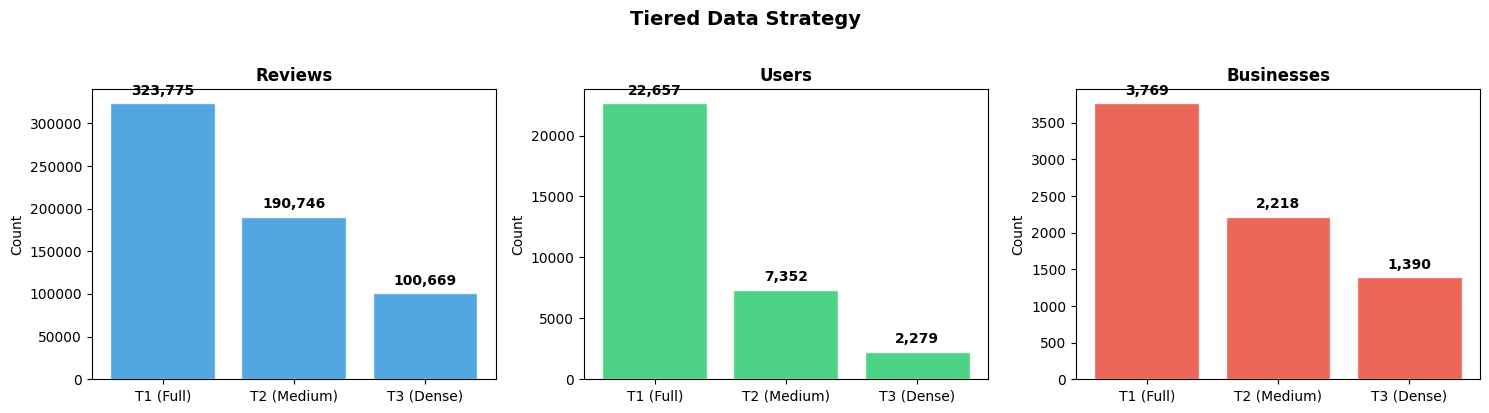

In [6]:
tier_summary = pd.DataFrame({
    'Tier': ['T1 (Full)', 'T2 (Medium)', 'T3 (Dense)'],
    'Purpose': ['Churn + EDA', 'Item-to-Item', 'SVD + NCF'],
    'User Min': [5, 10, 20],
    'Biz Min': [20, 30, 30],
    'Reviews': [len(reviews_t1), len(reviews_t2), len(reviews_t3)],
    'Users': [len(t1_user_ids), len(t2_user_ids), len(t3_user_ids)],
    'Businesses': [len(t1_biz_ids), len(t2_biz_ids), len(t3_biz_ids)],
    'Sparsity': [f"{t1_sparsity:.2%}", f"{t2_sparsity:.2%}", f"{t3_sparsity:.2%}"],
})
print(tier_summary.to_string(index=False))

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, metric, color in zip(axes, ['Reviews', 'Users', 'Businesses'], ['#3498db', '#2ecc71', '#e74c3c']):
    vals = tier_summary[metric].values
    bars = ax.bar(tier_summary['Tier'], vals, color=color, edgecolor='white', alpha=0.85)
    ax.set_title(metric, fontweight='bold')
    ax.set_ylabel('Count')
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + max(vals)*0.02,
                f'{val:,}', ha='center', va='bottom', fontweight='bold', fontsize=10)
plt.suptitle('Tiered Data Strategy', fontweight='bold', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

## 7. Build Final DataFrames & Save as Compressed `.csv.gz`

All files are saved as **gzip-compressed CSVs** (`.csv.gz`).  
Each file stays well under GitHub Desktop's **100 MB push limit**.  
`pandas` reads `.csv.gz` files natively — no extra decompression step needed.

In [7]:
# Build Tier 1 filtered DataFrames
biz = florida_biz[florida_biz['business_id'].isin(t1_biz_ids)].copy()
users = user_df[user_df['user_id'].isin(t1_user_ids)].copy()
reviews = reviews_t1.copy()
checkins = checkin_df[checkin_df['business_id'].isin(t1_biz_ids)].copy()
tips = tip_df[
    (tip_df['business_id'].isin(t1_biz_ids)) &
    (tip_df['user_id'].isin(t1_user_ids))
].copy()

reviews['date'] = pd.to_datetime(reviews['date'])
tips['date'] = pd.to_datetime(tips['date'])
checkins['n_checkins'] = checkins['date'].apply(
    lambda x: len(str(x).split(',')) if pd.notna(x) else 0
)

print(f"Tier 1 DataFrames built:")
print(f"  biz:      {biz.shape}")
print(f"  users:    {users.shape}")
print(f"  reviews:  {reviews.shape}")
print(f"  checkins: {checkins.shape}")
print(f"  tips:     {tips.shape}")

Tier 1 DataFrames built:
  biz:      (3769, 14)
  users:    (22657, 22)
  reviews:  (323775, 9)
  checkins: (3769, 3)
  tips:     (44936, 5)


In [8]:
OUTPUT_DIR = "/Users/danielregalado/Desktop/UM/1st Term Spring 2026/MAS 651 - Machine Learning Methods for Artificial Intelligence/Final project/FInal"
os.makedirs(OUTPUT_DIR, exist_ok=True)

datasets = {
    "tampa_businesses": biz,
    "tampa_reviews_t1": reviews,
    "tampa_reviews_t2": reviews_t2,
    "tampa_reviews_t3": reviews_t3,
    "tampa_users": users,
    "tampa_checkins": checkins,
    "tampa_tips": tips,
}

print("Saving compressed .csv.gz files...\n")
total_mb = 0
for name, df in datasets.items():
    path = os.path.join(OUTPUT_DIR, f"{name}.csv.gz")
    df.to_csv(path, index=False, compression='gzip')
    size_mb = os.path.getsize(path) / (1024**2)
    total_mb += size_mb
    print(f"  \u2713 {name}.csv.gz — {size_mb:.1f} MB  ({len(df):,} rows)")

print(f"\n{'='*60}")
print(f"  TOTAL: {total_mb:.1f} MB")
print(f"\u2713 All files saved to '{OUTPUT_DIR}'")
print(f"\nAll files are under 100 MB — safe to push via GitHub Desktop.")

Saving compressed .csv.gz files...

  ✓ tampa_businesses.csv.gz — 0.6 MB  (3,769 rows)
  ✓ tampa_reviews_t1.csv.gz — 94.0 MB  (323,775 rows)
  ✓ tampa_reviews_t2.csv.gz — 60.1 MB  (190,746 rows)
  ✓ tampa_reviews_t3.csv.gz — 35.0 MB  (100,669 rows)
  ✓ tampa_users.csv.gz — 35.5 MB  (22,657 rows)
  ✓ tampa_checkins.csv.gz — 5.9 MB  (3,769 rows)
  ✓ tampa_tips.csv.gz — 3.0 MB  (44,936 rows)

  TOTAL: 234.2 MB
✓ All files saved to '/Users/danielregalado/Desktop/UM/1st Term Spring 2026/MAS 651 - Machine Learning Methods for Artificial Intelligence/Final project/FInal'

All files are under 100 MB — safe to push via GitHub Desktop.


## 8. (Optional) Clean Up Raw Data

In [9]:
import shutil

# Uncomment to delete raw data after confirming CSVs look correct
# shutil.rmtree(DATA_DIR)
# print(f"\u2713 Raw data directory '{DATA_DIR}' removed.")

print("Done! Push 'preprocessed_data/' to your GitHub repo via GitHub Desktop.")

Done! Push 'preprocessed_data/' to your GitHub repo via GitHub Desktop.


---

## How to Load in the Main Notebook

Replace Sections 2–3.5 with this cell:

```python
PREPROCESS_DIR = "preprocessed_data/"

biz        = pd.read_csv(os.path.join(PREPROCESS_DIR, "tampa_businesses.csv.gz"))
reviews    = pd.read_csv(os.path.join(PREPROCESS_DIR, "tampa_reviews_t1.csv.gz"))
reviews_t2 = pd.read_csv(os.path.join(PREPROCESS_DIR, "tampa_reviews_t2.csv.gz"))
reviews_t3 = pd.read_csv(os.path.join(PREPROCESS_DIR, "tampa_reviews_t3.csv.gz"))
users      = pd.read_csv(os.path.join(PREPROCESS_DIR, "tampa_users.csv.gz"))
checkins   = pd.read_csv(os.path.join(PREPROCESS_DIR, "tampa_checkins.csv.gz"))
tips       = pd.read_csv(os.path.join(PREPROCESS_DIR, "tampa_tips.csv.gz"))

reviews['date'] = pd.to_datetime(reviews['date'])
reviews_t2['date'] = pd.to_datetime(reviews_t2['date'])
reviews_t3['date'] = pd.to_datetime(reviews_t3['date'])
tips['date'] = pd.to_datetime(tips['date'])

t1_user_ids = set(reviews['user_id'].unique())
t1_biz_ids  = set(reviews['business_id'].unique())
t2_user_ids = set(reviews_t2['user_id'].unique())
t2_biz_ids  = set(reviews_t2['business_id'].unique())
t3_user_ids = set(reviews_t3['user_id'].unique())
t3_biz_ids  = set(reviews_t3['business_id'].unique())

print(f"Loaded preprocessed data:")
print(f"  T1: {len(reviews):,} reviews | {len(t1_user_ids):,} users | {len(t1_biz_ids):,} biz")
print(f"  T2: {len(reviews_t2):,} reviews | {len(t2_user_ids):,} users | {len(t2_biz_ids):,} biz")
print(f"  T3: {len(reviews_t3):,} reviews | {len(t3_user_ids):,} users | {len(t3_biz_ids):,} biz")
```